In [6]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import jax
import jax.numpy as jnp
import copy
import optax
from scipy import io
import equinox as eqx

# Import from tvboptim
from tvboptim.types import Parameter, BoundedParameter
from tvboptim.types.stateutils import show_parameters
from tvboptim.utils import set_cache_path, cache
from tvboptim.optim.optax import OptaxOptimizer
from tvboptim.optim.callbacks import MultiCallback, DefaultPrintCallback, SavingLossCallback

# Network dynamics imports
from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang
from tvboptim.experimental.network_dynamics.coupling import LinearCoupling, FastLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph, DenseGraph
from tvboptim.experimental.network_dynamics.solvers import Heun, BoundedSolver
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.data import load_structural_connectivity, load_functional_connectivity

# BOLD monitoring
from tvboptim.observations.tvb_monitors.bold import Bold

# Observation functions
from tvboptim.observations.observation import compute_fc, fc_corr, rmse

# Caching utilities
from tvboptim.utils import set_cache_path, cache


In [25]:
# load the parameters and the structural connectivity
metrics = ["ADC", "gFA", "number", "density"]
J_i = {}
wFFI = {}
wLRE = {}
SC_all = {}
for metric in metrics:
    J_i[metric] = {}
    wFFI[metric] = {}   
    wLRE[metric] = {}
    SC_all[metric] = {}

    SC_all[metric]=np.load(f"/Users/lin/Documents/Bachelor thesis /SC_matrices/{metric}/{metric}_allsubj_Hagmann.npy", allow_pickle=True).item()
    for subj in SC_all[metric].keys():
        path = f"/Users/lin/Documents/Bachelor thesis /E_I tuning model/{metric}/{metric}_param_83_{subj}.npy"
        file = np.load(path, allow_pickle=True).item()
        J_i[metric][subj] = file["J_i"]
        wFFI[metric][subj] = file["wFFI"]
        wLRE[metric][subj] = file["wLRE"]

region = np.load("/Users/lin/Documents/Bachelor thesis /reg_labels_Hagmann83.npy", allow_pickle=True)
print(region)
print(SC_all[metric]['schz1'].keys())
region_labels = np.load("/Users/lin/Documents/Bachelor thesis /Data/reg_labels_Hagmann129.npy", allow_pickle=True)
print(region_labels).keys()



KeyboardInterrupt: 

In [27]:
region = np.load("/Users/lin/Documents/Bachelor thesis /reg_labels_Hagmann83.npy", allow_pickle=True)
print(region)
region = np.load("/Users/lin/Documents/Bachelor thesis /reg_labels_Hagmann129.npy", allow_pickle=True)
print(region)

[b'rh_lateralorbitofrontal' b'rh_parsorbitalis' b'rh_frontalpole'
 b'rh_medialorbitofrontal' b'rh_parstriangularis' b'rh_parsopercularis'
 b'rh_rostralmiddlefrontal' b'rh_superiorfrontal'
 b'rh_caudalmiddlefrontal' b'rh_precentral' b'rh_paracentral'
 b'rh_rostralanteriorcingulate' b'rh_caudalanteriorcingulate'
 b'rh_posteriorcingulate' b'rh_isthmuscingulate' b'rh_postcentral'
 b'rh_supramarginal' b'rh_superiorparietal' b'rh_inferiorparietal'
 b'rh_precuneus' b'rh_cuneus' b'rh_pericalcarine' b'rh_lateraloccipital'
 b'rh_lingual' b'rh_fusiform' b'rh_parahippocampal' b'rh_entorhinal'
 b'rh_temporalpole' b'rh_inferiortemporal' b'rh_middletemporal'
 b'rh_bankssts' b'rh_superiortemporal' b'rh_transversetemporal'
 b'rh_insula' b'rh_thalamusproper' b'rh_caudate' b'rh_putamen'
 b'rh_pallidum' b'rh_accumbensarea' b'rh_hippocampus' b'rh_amygdala'
 b'lh_lateralorbitofrontal' b'lh_parsorbitalis' b'lh_frontalpole'
 b'lh_medialorbitofrontal' b'lh_parstriangularis' b'lh_parsopercularis'
 b'lh_rostralm

In [8]:
# prepare network and run forward simulation

results = {}
# path to results
results_path = "/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results"
weights = SC_all['ADC']['schz1'][83]


# define class ReducedWongWangEIB:
from typing import Tuple
from tvboptim.experimental.network_dynamics.dynamics.base import AbstractDynamics
from tvboptim.experimental.network_dynamics.core.bunch import Bunch

class ReducedWongWangEIB(AbstractDynamics):
    """Two-population Reduced Wong-Wang model with E-I balance support"""

    STATE_NAMES = ('S_e', 'S_i')
    INITIAL_STATE = (0.001, 0.001)
    AUXILIARY_NAMES = ('H_e', 'H_i')

    DEFAULT_PARAMS = Bunch(
        # Excitatory population parameters
        a_e=310.0,         # Input gain parameter
        b_e=125.0,         # Input shift parameter [Hz]
        d_e=0.160,         # Input scaling parameter [s]
        gamma_e=0.641/1000,  # Kinetic parameter
        tau_e=100.0,       # NMDA decay time constant [ms]
        w_p=1.4,           # Excitatory recurrence weight
        W_e=1.0,           # External input scaling weight

        # Inhibitory population parameters
        a_i=615.0,         # Input gain parameter
        b_i=177.0,         # Input shift parameter [Hz]
        d_i=0.087,         # Input scaling parameter [s]
        gamma_i=1.0/1000,  # Kinetic parameter
        tau_i=10.0,        # NMDA decay time constant [ms]
        W_i=0.7,           # External input scaling weight

        # Synaptic weights
        J_N=0.15,          # NMDA current [nA]
        J_i=1.0,           # Inhibitory synaptic weight

        # External inputs
        I_o=0.382,         # Background input current
        I_ext=0.0,         # External stimulation current

        # Coupling parameters
        lamda=1.0,         # Lambda: inhibitory coupling scaling
    )

    COUPLING_INPUTS = {
        'coupling': 2,  # Long-range excitation and Feedforward inhibition
    }
    EXTERNAL_INPUTS = {
        'stim': 1
    }

    def dynamics(
        self,
        t: float,
        state: jnp.ndarray,
        params: Bunch,
        coupling: Bunch,
        external: Bunch
    ) -> Tuple[jnp.ndarray, jnp.ndarray]:
        """Compute two-population Wong-Wang dynamics with dual coupling."""

        # Unpack state variables
        S_e = state[0]  # Excitatory synaptic gating
        S_i = state[1]  # Inhibitory synaptic gating

        # Unpack coupling inputs
        c_lre = params.J_N * coupling.coupling[0]  # Long-range excitation
        c_ffi = params.J_N * coupling.coupling[1]  # Feedforward inhibition
        
        I_stim = external.stim[0]

        # Excitatory population input
        J_N_S_e = params.J_N * S_e
        x_e_pre = (params.w_p * J_N_S_e - params.J_i * S_i +
                params.W_e * params.I_o + c_lre + params.I_ext + I_stim)
        

        # Excitatory transfer function
        x_e = params.a_e * x_e_pre - params.b_e
        H_e = x_e / (1.0 - jnp.exp(-params.d_e * x_e))

        # Excitatory dynamics
        dS_e_dt = -(S_e / params.tau_e) + (1.0 - S_e) * H_e * params.gamma_e

        # Inhibitory population input
        x_i_pre = J_N_S_e - S_i + params.W_i * params.I_o + params.lamda * c_ffi + I_stim

        # Inhibitory transfer function
        x_i = params.a_i * x_i_pre - params.b_i
        H_i = x_i / (1.0 - jnp.exp(-params.d_i * x_i))

        # Inhibitory dynamics
        dS_i_dt = -(S_i / params.tau_i) + H_i * params.gamma_i

        # Package results
        derivatives = jnp.array([dS_e_dt, dS_i_dt])
        auxiliaries = jnp.array([H_e, H_i])

        return derivatives, auxiliaries
    
    
from tvboptim.experimental.network_dynamics.coupling.base import InstantaneousCoupling

class EIBLinearCoupling(InstantaneousCoupling):
    """EIB Linear coupling with separate excitatory and inhibitory weight matrices.

    This coupling produces two outputs:
        c_lre: Long-range excitation (wLRE * S_e)
        c_ffi: Feedforward inhibition (wFFI * S_e)

    Both couplings are driven by the excitatory activity (S_e) from other regions.
    """

    N_OUTPUT_STATES = 2  # Produces two coupling outputs

    DEFAULT_PARAMS = Bunch(
        wLRE = 1.0,  # Long-range excitation weight matrix
        wFFI = 1.0,  # Feedforward inhibition weight matrix
    )

    def pre(
        self,
        incoming_states: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Pre-synaptic transformation: multiply S_e with wLRE and wFFI."""
        # incoming_states[0] is S_e from all source nodes
        S_e = incoming_states[0]  # [n_target, n_source]
        # Apply weights: element-wise multiply S_e with each weight matrix
        # params.wLRE and params.wFFI have shape [n_nodes, n_nodes]
        c_lre = S_e * params.wLRE  # [n_target, n_source]
        c_ffi = S_e * params.wFFI  # [n_target, n_source]

        # Stack into [2, n_target, n_source]
        return jnp.stack([c_lre, c_ffi], axis=0)

    def post(
        self,
        summed_inputs: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Post-synaptic transformation: pass through without scaling."""
        return summed_inputs

graph    = DenseGraph(weights, region_labels=region_labels)
dynamics = ReducedWongWangEIB(J_i=J_i['ADC']['schz1'])
coupling = EIBLinearCoupling(incoming_states=["S_e"])
coupling.params.wLRE = wLRE['ADC']['schz1']
coupling.params.wFFI = wFFI['ADC']['schz1']

network = Network(
    dynamics=dynamics,
    coupling={"coupling": coupling},
    graph=graph,
    noise=AdditiveNoise(sigma=0.01, apply_to="S_e")
)

# Transient simulation to reach steady state
dt     = 4.0
solver = BoundedSolver(Heun(), low=0.0, high=1.0)

model_init, state_init = prepare(network, solver, t1=5*60_000, dt=dt)
print("Running transient...")
result_init = jax.block_until_ready(model_init(state_init))
network.update_history(result_init)

bold_TR = 720.0
t1_long = 60_000  # 1 Minute

bold_monitor = Bold(
    period=bold_TR,
    downsample_period=dt,
    voi=0,
    history=result_init
)

model_long, state_long = prepare(network, solver, t1=t1_long, dt=dt)

state_long.dynamics.J_i            = J_i['ADC']['schz1']
state_long.coupling.coupling.wLRE  = wLRE['ADC']['schz1']
state_long.coupling.coupling.wFFI  = wFFI['ADC']['schz1']

print("Running forward simulation...")

raw_result = model_long(state_long)
print(raw_result.variable_names)
bold_signal = bold_monitor(raw_result)





Running transient...


/var/folders/j2/mxj6mdd50nd0rsyvbthcl0br0000gn/T/ipykernel_93334/3253054208.py:178: DeprecationWarning: Bold is deprecated and will be removed in a future version. Use HRFBold (HRF convolution) or BalloonWindkesselBold (ODE integration) explicitly.
  bold_monitor = Bold(


Running forward simulation...
('S_e', 'S_i')


83


/var/folders/j2/mxj6mdd50nd0rsyvbthcl0br0000gn/T/ipykernel_55116/2605158279.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


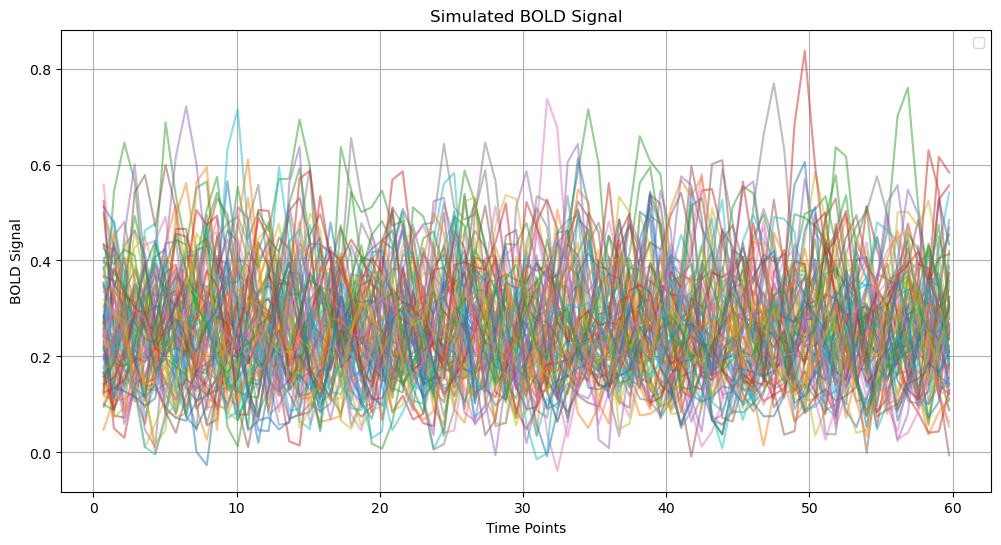

In [8]:
# visualize the BOLD signal
import matplotlib.pyplot as plt
import numpy as np

data = bold_signal.data.squeeze()
print(len(data))

time_s = bold_signal.time / 1000.0

plt.figure(figsize=(12, 6))
plt.plot(time_s, data, alpha=0.5)
plt.title('Simulated BOLD Signal')
plt.xlabel('Time Points')
plt.ylabel('BOLD Signal')
plt.legend()
plt.grid()
plt.show()


In [7]:
from tvboptim.experimental.network_dynamics.solve import prepare
from tvboptim.experimental.network_dynamics.external_input import PulseInput

# define labels for classification of participants
labels = []
subject_ids = []
results = {}
# Transient time:
trans = 5*60_000
SUBJECTS = SC_all[metric].keys()
AMPLITUDE = 0.01
SPLITS = 10
DURATION = 500 #in ms
SEED = 100
PATH = f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/S_i_S_e/10subj_{DURATION}_{AMPLITUDE}_{SEED}.npy"
PATH_LABEL = f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/S_i_S_e/10subj_{DURATION}_{AMPLITUDE}_{SEED}_labels.npy"


subjects = SUBJECTS
metrics = ['ADC']
for metric in metrics:
        results[metric] = {}
        for subj in subjects:
            print(subj)
            # print(type(wFFI[metric][subj]), type(wLRE[metric][subj]), type(J_i[metric][subj]))
            weights = SC_all[metric][subj][83]
            graph    = DenseGraph(weights, region_labels=region_labels)
            dynamics = ReducedWongWangEIB(J_i=jnp.array((J_i[metric][subj])))
            coupling = EIBLinearCoupling(incoming_states=["S_e"])
            coupling.params.wLRE = jnp.array(wLRE[metric][subj])
            coupling.params.wFFI = jnp.array(wFFI[metric][subj])
            results[metric][subj] = {}


            # define the stimulus:
            stim_dur = DURATION

            # define noise and set seed:
            # first 50 with stimulus and last 50 without stimulus, to see the difference in BOLD signal
            # 10 splits
            for seed in range(SEED):
                results[metric][subj][seed] = {}
                # for ampl in [0.0, 10]:
                noise = AdditiveNoise(sigma=0.01, apply_to="S_e", key=jax.random.key(seed))

                network = Network(
                            dynamics=dynamics,
                            coupling={"coupling": coupling},
                            graph=graph,
                            noise=noise
                        )
                # Transient simulation to reach steady state
                dt     = 4.0
                solver = BoundedSolver(Heun(), low=0.0, high=1.0)

                model_init, state_init = prepare(network, solver, t1=5*60_000, dt=dt)
                print("Running transient for seed " + str(seed) + "..." )
                result_init = jax.block_until_ready(model_init(state_init))
                network.update_history(result_init)

                if seed > 49:
                        ampl = AMPLITUDE
                        group = 1
                else:
                        ampl = 0.0
                        group = 0
                print(seed)

                dur = stim_dur
                labels.append(group)
                subject_ids.append(subj)

                bold_TR = 720.0
                t1_long = 5000

                stim_region_idx = [27,31, 71, 68, 72, 30]
                stim_ampl_l = np.zeros(len(region_labels))
                stim_ampl_l[stim_region_idx] = ampl
                stim = PulseInput(onset=t1_long/2, duration=dur, amplitude=stim_ampl_l)
                results[metric][subj][seed][(ampl, dur)] = []

                network_stim = Network(
                        dynamics=dynamics,
                        coupling={"coupling": coupling},
                        graph=graph,
                        noise=noise,
                        external_input={"stim":  stim}
                    )
                network_stim.update_history(result_init)


                bold_monitor = Bold(
                    period=bold_TR,
                    downsample_period=dt,
                    voi=0,
                    history=result_init
                )

                model_long, state_long = prepare(network_stim, solver, t1=t1_long, dt=dt, )


                state_long.dynamics.J_i            = J_i[metric][subj]
                state_long.coupling.coupling.wLRE  = wLRE[metric][subj]
                state_long.coupling.coupling.wFFI  = wFFI[metric][subj]

                print(f"Running forward simulation, {seed}, {subj}, {ampl} ...")

                raw_result = model_long(state_long)

                bold_signal = bold_monitor(raw_result)
                # data = bold_signal.data.squeeze()
                data = raw_result.data.squeeze()
                # data_diff = jnp.array(data - temp)

                # visualization
                time_s = bold_signal.time / 1000.0
                results[metric][subj][seed][(ampl, dur)].append(data)
                print(results[metric][subj][seed].keys())

                # plt.figure(figsize=(12, 6))
                # for idx in stim_region_idx:
                #     plt.plot(time_s, data_diff[:, idx], alpha=0.5)
                #     # plt.plot(time_s, data[:, idx], label=region_labels[idx], linestyle='--')
                #     # plt.plot(time_s, temp[:, idx], label=region_labels[idx], alpha=0.3)
                # plt.title('Simulated BOLD Signal, stim_dur: ' + str(dur) + ' Amplitude: ' + str(ampl) + "seed" + str(seed))
                # plt.xlabel('Time Points')
                # plt.ylabel('BOLD Signal')
                # plt.legend()
                # plt.grid()
                # # plt.savefig(f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/BOLD/diff/{metric}_{subj}_seed{seed}_stimdur{dur}_ampl{ampl}.pdf")
                # plt.show()
                
                
                ## plot the differences
                
                # plt.figure(figsize=(12, 6))
                # for idx in stim_region_idx:
                #     plt.plot(time_s, data[:, idx], label=region_labels[idx])
                # plt.title('Simulated BOLD Signal, Duration: ' + str(dur) + 'ms, Amplitude: ' + str(ampl) + ", seed" + str(seed))
                # plt.xlabel('Time Points')
                # plt.ylabel('BOLD Signal')
                # plt.legend()
                # plt.grid()
                # plt.savefig(f"/Users/lin/Documents/Bachelor thesis/hallucinations/simulations/results/BOLD/{metric}_{subj}_seed{seed}_stimdur{dur}_ampl{ampl}.pdf")
                # plt.show()

                # temp = data

labels      = np.array(labels)       # shape: [number of subjects * number of stim conditions * number of seeds]
subject_ids = np.array(subject_ids)
np.save(f"{PATH}.npy", results)
np.save({f"PATH_LABEL".npy}, labels)


schz0
Running transient for seed 0...
0


/var/folders/j2/mxj6mdd50nd0rsyvbthcl0br0000gn/T/ipykernel_78962/3234655575.py:99: DeprecationWarning: Bold is deprecated and will be removed in a future version. Use HRFBold (HRF convolution) or BalloonWindkesselBold (ODE integration) explicitly.
  bold_monitor = Bold(


Running forward simulation, 0, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 1...
1
Running forward simulation, 1, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 2...
2
Running forward simulation, 2, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 3...
3
Running forward simulation, 3, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 4...
4
Running forward simulation, 4, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 5...
5
Running forward simulation, 5, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 6...
6
Running forward simulation, 6, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 7...
7
Running forward simulation, 7, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 8...
8
Running forward simulation, 8, schz0, 0.0 ...
dict_keys([(0.0, 500)])
Running transient for seed 9...
9
Running forward simulation, 9, schz0, 0.0 ...
dict_keys([(0.0, 5

In [129]:
# get the index of region_labels for the following regions:
regions_of_interest = [b'rh_temporalpole', b'rh_superiortemporal', b'lh_bankssts', b'lh_temporalpole', b'lh_superiortemporal',  b'rh_bankssts']
roi_indices = [np.where(region_labels == roi)[0][0] for roi in regions_of_interest]
print(roi_indices)

[np.int64(27), np.int64(31), np.int64(71), np.int64(68), np.int64(72), np.int64(30)]


In [9]:
# classification using SGD
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# temp_results = results
# temp_labels = labels

metric = 'ADC'
AMPLITUDE = 0.01
SPLITS = 20
DURATION = 500 #in ms
SEED = 100
PATH = f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/S_i_S_e/10subj_{DURATION}_{AMPLITUDE}_{SEED}"
PATH_LABEL = f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/S_i_S_e/10subj_{DURATION}_{AMPLITUDE}_{SEED}_labels"
PATH_ACCURACY = f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/S_i_S_e/all_{DURATION}_{AMPLITUDE}_{SEED}_accuracy"
SUBJECTS = SC_all[metric].keys()
# Load the results and labels
results = np.load(PATH, allow_pickle=True).item()
labels = np.load(PATH_LABEL)


subjects = results['ADC'].keys()
print(subjects)
# Prepare the data for classification
nsplits = SPLITS


accuracies_ctrl = []
accuracies_schz = []
accuracies_all  = []
FP_per_subj = {}
FP = []
FN_per_subj = {}
for subj in subjects:
    X = []
    y = []
    FP_per_subj[subj] = []
    FN_per_subj[subj] = []

    print(subj)
    for seed in range(SEED):
        if seed > (SEED // 2 - 1):
            X.append(np.array(results[metric][subj][seed][(AMPLITUDE, DURATION)]))
            y.append(1)
        else:
            X.append(np.array(results[metric][subj][seed][(0.0, DURATION)]))
            y.append(0)
    X = np.array(X)
    X = X.reshape(100, -1)
            
    for ii_split in range(nsplits):
                    ctr = 0  
                    X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=ii_split, stratify=y)
                    clf = make_pipeline(StandardScaler(),
                                SGDClassifier(loss = 'perceptron', penalty='l2', max_iter=5000, tol=5e-3))
                    clf.fit(X_train, y_train)
                    
                    y_pred = clf.predict(X_test)
                    accuracy = accuracy_score(y_test, y_pred)
                    cm = confusion_matrix(y_test, y_pred)
                    TN, FP, FN, TP = cm.ravel()
                    FP_per_subj[subj].append(FP)
                    FN_per_subj[subj].append(FN)
                    
                    print(ii_split, f' Accuracy: {accuracy}')
                    accuracies_all.append(accuracy)
                    
                    if 'schz' in subj:
                        accuracies_schz.append(accuracy)
                        print("Schz")
                    else:
                        accuracies_ctrl.append(accuracy)
                        print("Ctrl")
                    ctr+= 1

print(f"Overall accuracy:       {np.mean(accuracies_all):.7f} ± {np.std(accuracies_all):.3f}")
print(f"Control accuracy:       {np.mean(accuracies_ctrl):.7f} ± {np.std(accuracies_ctrl):.3f}")
print(f"Schizophrenia accuracy: {np.mean(accuracies_schz):.7f} ± {np.std(accuracies_schz):.3f}")

# save data
np.save(f"{PATH_ACCURACY}_all.npy", accuracies_all)
np.save(f"{PATH_ACCURACY}_ctrl.npy", accuracies_ctrl)
np.save(f"{PATH_ACCURACY}_schz.npy", accuracies_schz)
np.save(f"{PATH_ACCURACY}_FP.npy", FP_per_subj)
np.save(f"{PATH_ACCURACY}_FN.npy", FN_per_subj)
# np.save("/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/ampl_0.05/short_sim_all_accuracies_ctrl.npy", accuracies_ctrl)
# np.save("/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/ampl_0.05/short_sim_all_accuracies_schz.npy", accuracies_schz)
# np.save("/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/ampl_0.05/short_sim_all_FP_per_subj.npy", FP_per_subj)
# np.save("/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/ampl_0.05/short_sim_all_FN_per_subj.npy", FN_per_subj)

dict_keys(['schz0', 'schz1', 'schz2', 'schz3', 'schz4', 'schz5', 'schz6', 'schz7', 'schz8', 'schz9', 'schz10', 'schz11', 'schz12', 'schz13', 'schz14', 'schz15', 'schz16', 'schz17', 'schz18', 'schz19', 'schz20', 'schz21', 'schz22', 'schz23', 'schz24', 'schz25', 'schz26', 'ctrl0', 'ctrl1', 'ctrl2', 'ctrl3', 'ctrl4', 'ctrl5', 'ctrl6', 'ctrl7', 'ctrl8', 'ctrl9', 'ctrl10', 'ctrl11', 'ctrl12', 'ctrl13', 'ctrl14', 'ctrl15', 'ctrl16', 'ctrl17', 'ctrl18', 'ctrl19', 'ctrl20', 'ctrl21', 'ctrl22', 'ctrl23', 'ctrl24', 'ctrl25', 'ctrl26'])
schz0
0  Accuracy: 0.7
Schz
1  Accuracy: 0.65
Schz
2  Accuracy: 0.5
Schz
3  Accuracy: 0.7
Schz
4  Accuracy: 0.65
Schz
5  Accuracy: 0.6
Schz
6  Accuracy: 0.65
Schz
7  Accuracy: 0.8
Schz
8  Accuracy: 0.7
Schz
9  Accuracy: 0.7
Schz
10  Accuracy: 0.55
Schz
11  Accuracy: 0.75
Schz
12  Accuracy: 0.65
Schz
13  Accuracy: 0.8
Schz
14  Accuracy: 0.7
Schz
15  Accuracy: 0.65
Schz
16  Accuracy: 0.55
Schz
17  Accuracy: 0.65
Schz
18  Accuracy: 0.65
Schz
19  Accuracy: 0.6
Schz
sc

In [11]:
np.save(f"{PATH_ACCURACY}_FP.npy", FP_per_subj)
np.save(f"{PATH_ACCURACY}_FN.npy", FN_per_subj)

Control accuracy:       0.6692685 ± 0.109
Schizophrenia accuracy: 0.6875278 ± 0.107
5400 5400


/var/folders/j2/mxj6mdd50nd0rsyvbthcl0br0000gn/T/ipykernel_93334/2047308289.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='Accuracy', data=df, palette='Set2')


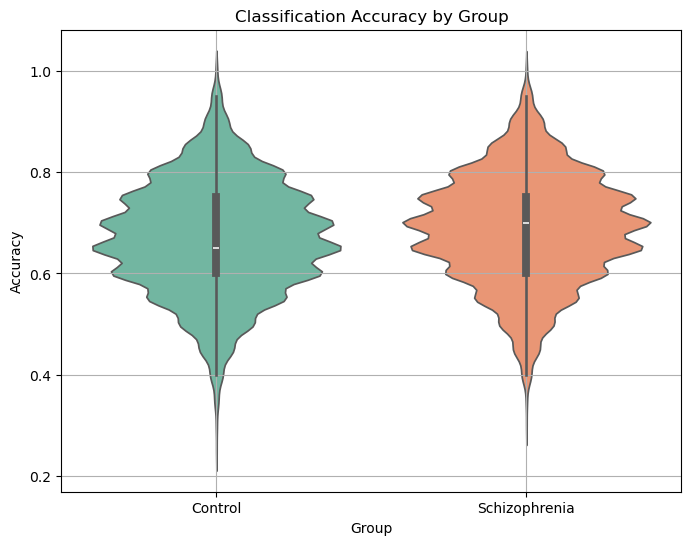

Control vs Schz: t=114.012, p=0.000
Schizophrenia vs Chance: t=129.072, p=0.000


In [23]:
# load data
# accuracies_ctrl = np.load(f"{PATH_ACCURACY}_ctrl.npy")
# accuracies_schz = np.load(f"{PATH_ACCURACY}_schz.npy")
accuracies_ctrl = np.load(f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/BOLD classification/ampl_0.05/short_sim_schz0_ctrl0_accuracies_ctrl.npy")
accuracies_schz = np.load(f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/BOLD classification/ampl_0.05/short_sim_schz0_ctrl0_accuracies_schz.npy")

print(f"Control accuracy:       {np.mean(accuracies_ctrl):.7f} ± {np.std(accuracies_ctrl):.3f}")
print(f"Schizophrenia accuracy: {np.mean(accuracies_schz):.7f} ± {np.std(accuracies_schz):.3f}")

# Violin plot comparison
import seaborn as sns
import pandas as pd

# Prepare DataFrame for seaborn
print(len(accuracies_ctrl), len(accuracies_schz))
df = pd.DataFrame({
    'Accuracy':  list(accuracies_ctrl) + list(accuracies_schz),
    'Group': (['Control'] * len(accuracies_ctrl)) +
             (['Schizophrenia'] * len(accuracies_schz))
})
plt.figure(figsize=(8, 6))
sns.violinplot(x='Group', y='Accuracy', data=df, palette='Set2')
plt.title('Classification Accuracy by Group')
plt.ylabel('Accuracy')
plt.grid()
plt.savefig(f"{PATH_ACCURACY}_plot.pdf")
plt.show()

# statistical test
from scipy.stats import ttest_ind
from scipy.stats import ttest_1samp
t_stat_ctrl, p_value_ctrl = ttest_ind(accuracies_ctrl, accuracies_schz)
t_stat_schz, p_value_schz = ttest_1samp(accuracies_schz, 0.5)
t_stat_ctrl, p_value_ctrl = ttest_1samp(accuracies_ctrl, 0.5)
print(f"Control vs Schz: t={t_stat_ctrl:.3f}, p={p_value_ctrl:.3f}")
print(f"Schizophrenia vs Chance: t={t_stat_schz:.3f}, p={p_value_schz:.3f}")


Mann-Whitney U: stat=436.000, p=0.2193
Effect size (r): -0.196
t-test: stat=1.241, p=0.2201


/var/folders/j2/mxj6mdd50nd0rsyvbthcl0br0000gn/T/ipykernel_93334/4120763013.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='False Positives', data=df_FP, palette='Set2', )


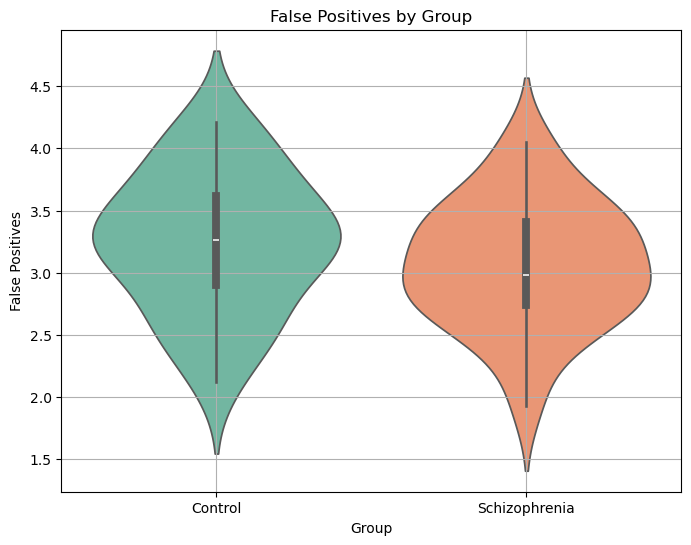

In [24]:
# load data
# FP_per_subj = np.load(f"{PATH_ACCURACY}_FP.npy", allow_pickle=True).item()
# FN_per_subj = np.load(f"{PATH_ACCURACY}_FN.npy", allow_pickle=True).item()

FP_per_subj = np.load(f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/BOLD classification/ampl_0.05/short_sim_schz0_ctrl0_FP_per_subj.npy", allow_pickle=True).item()
FN_per_subj = np.load(f"/Users/lin/Documents/Bachelor thesis /hallucinations/simulations/results/BOLD classification/ampl_0.05/short_sim_schz0_ctrl0_FN_per_subj.npy", allow_pickle=True).item()

# Quantities of false Positives 
# accuracies_ctrl = np.array(accuracies_ctrl)
# accuracies_ctrl = accuracies_ctrl.reshape(27,n_splits)
FP_schz = []
FP_ctrl = []
FN_schz = []
FN_ctrl = []
    
# violin plots of the TP 
# 1. average across the splits for each subject
avg_FP_per_subj = {}
for subj in subjects:
    avg_FP_per_subj[subj] = np.mean(FP_per_subj[subj])
    # print(avg_FP_per_subj[subj])
    
    if 'schz' in subj:
        FP_schz.append(avg_FP_per_subj[subj])
    else:
        FP_ctrl.append(avg_FP_per_subj[subj])

# statistical testing if they are significantly different 

from scipy import stats

# Mann-Whitney U test (non-parametric, doesn't assume normality)
stat, p = stats.mannwhitneyu(FP_ctrl, FP_schz, alternative='two-sided')
print(f"Mann-Whitney U: stat={stat:.3f}, p={p:.4f}")

# Also compute effect size (rank-biserial correlation)
n1, n2 = len(FP_ctrl), len(FP_schz)
effect_size = 1 - (2 * stat) / (n1 * n2)
print(f"Effect size (r): {effect_size:.3f}")

# If you want t-test as well for comparison:
stat_t, p_t = stats.ttest_ind(FP_ctrl, FP_schz)
print(f"t-test: stat={stat_t:.3f}, p={p_t:.4f}")

# Visualization using violin plots to compare both groups

import seaborn as sns
import pandas as pd

df_FP = pd.DataFrame({
    'False Positives': np.concatenate([FP_ctrl, FP_schz]),
    'Group': ['Control'] * len(FP_ctrl) + ['Schizophrenia'] * len(FP_schz)
})

plt.figure(figsize=(8, 6))
sns.violinplot(x='Group', y='False Positives', data=df_FP, palette='Set2', )
plt.title('False Positives by Group')
plt.grid()
# plt.savefig(f"{PATH_ACCURACY}_FP_plot.pdf")
plt.show()

    


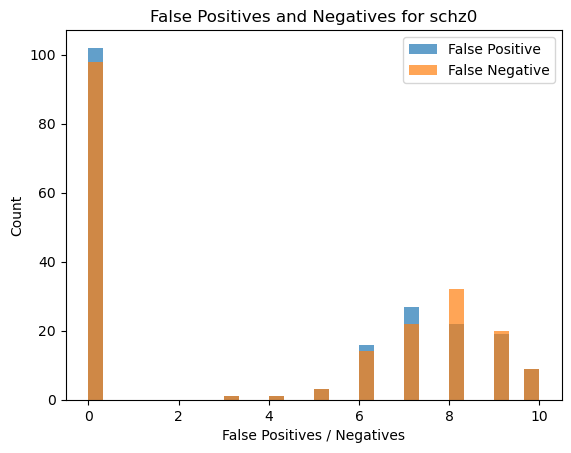

5400 5400


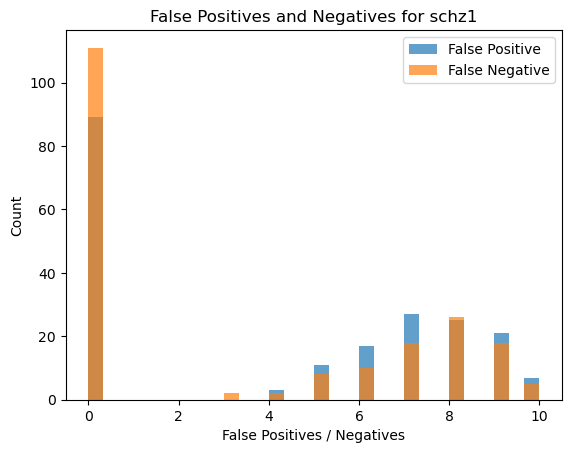

5400 5400


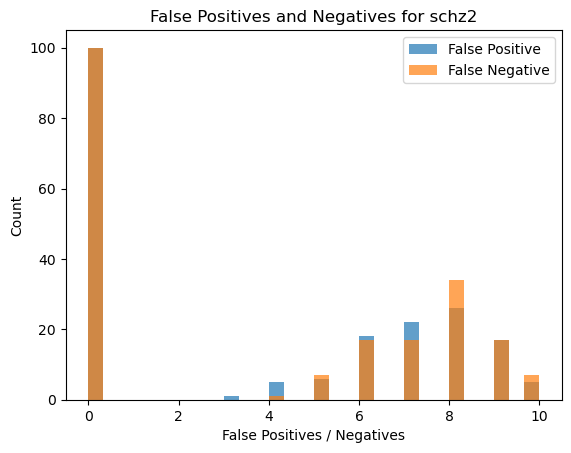

5400 5400


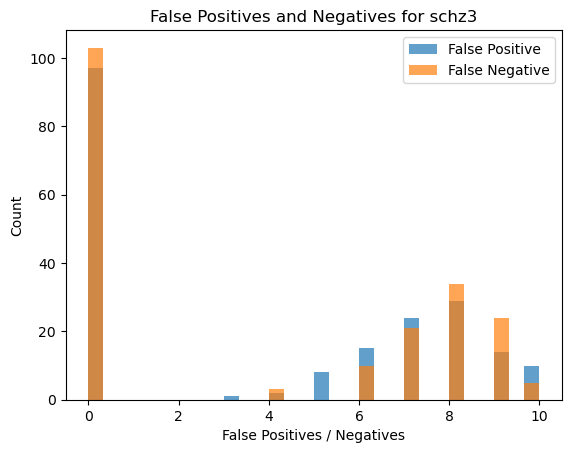

5400 5400


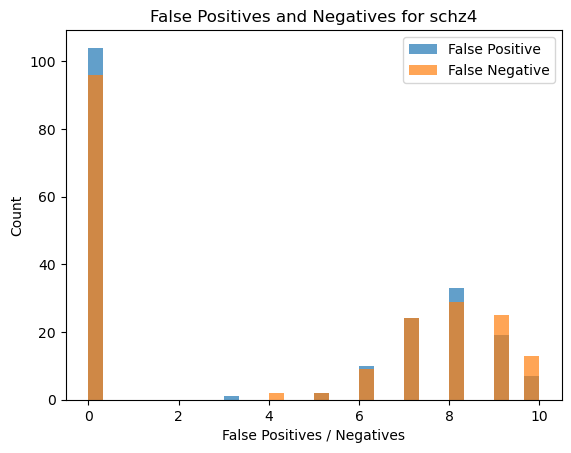

5400 5400


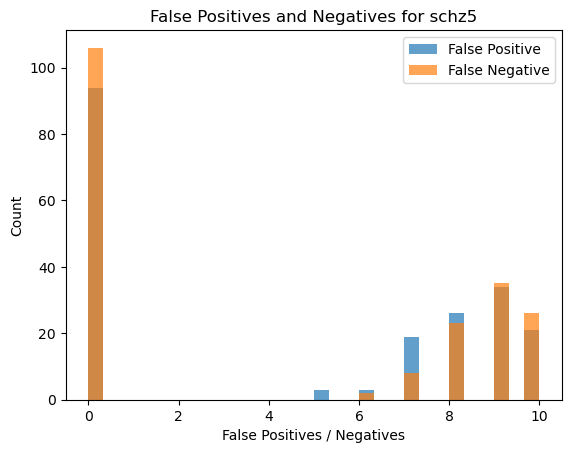

5400 5400


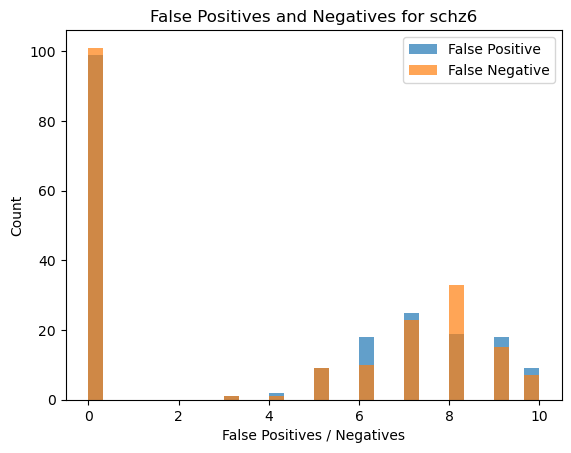

5400 5400


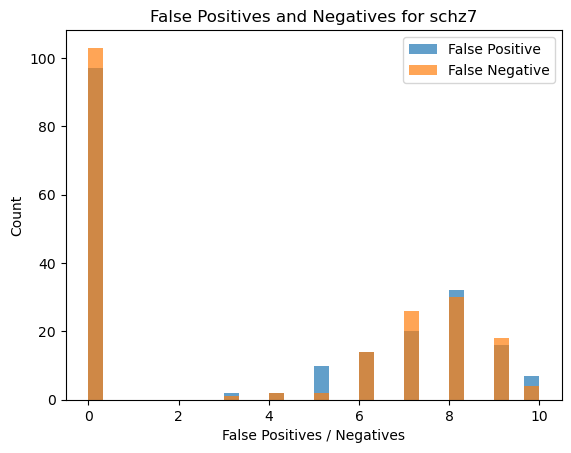

5400 5400


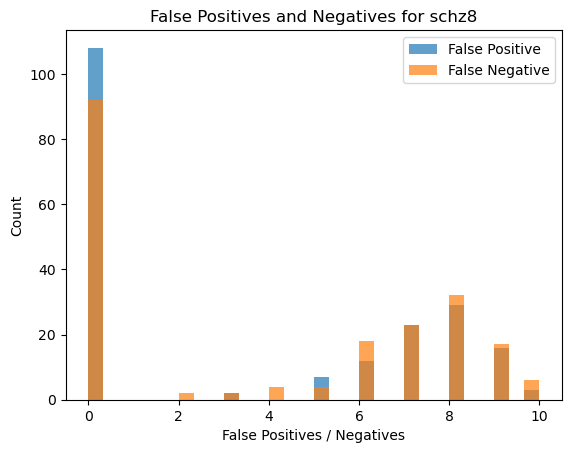

5400 5400


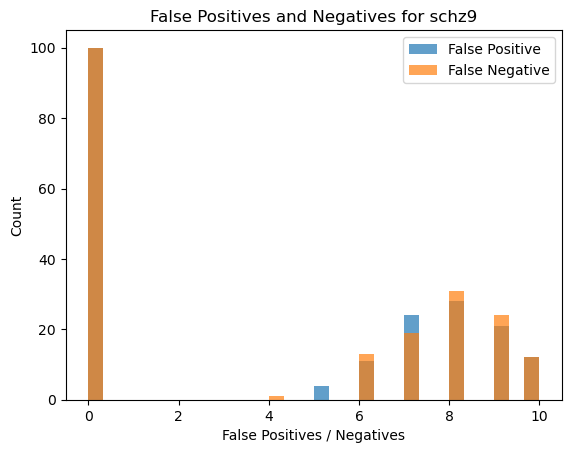

5400 5400


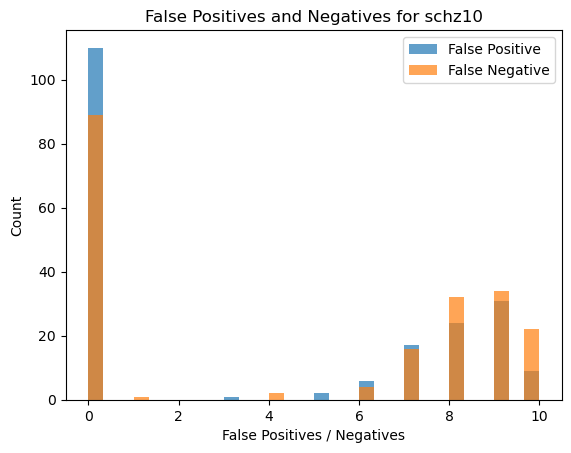

5400 5400


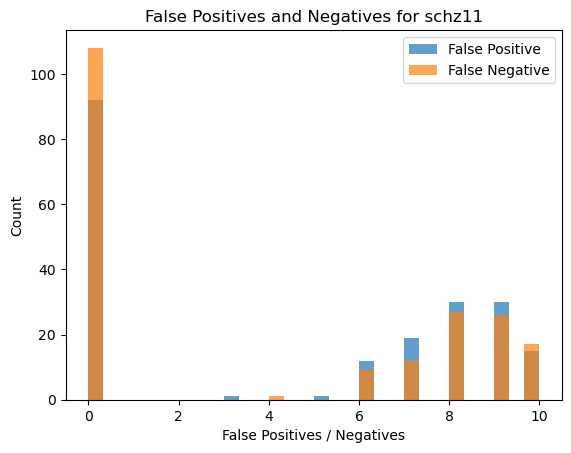

5400 5400


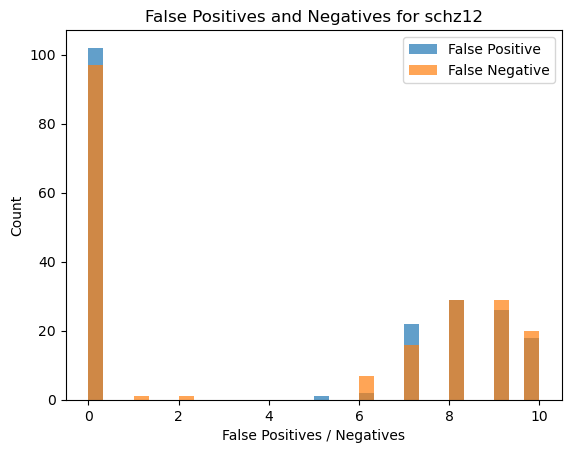

5400 5400


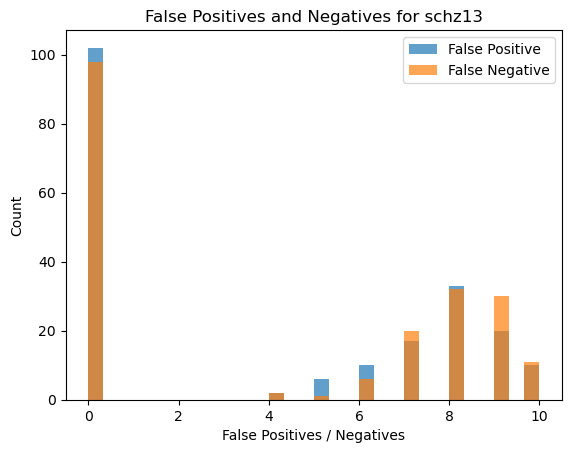

5400 5400


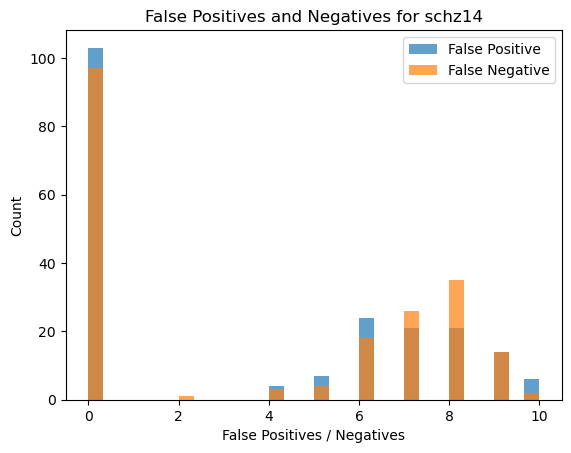

5400 5400


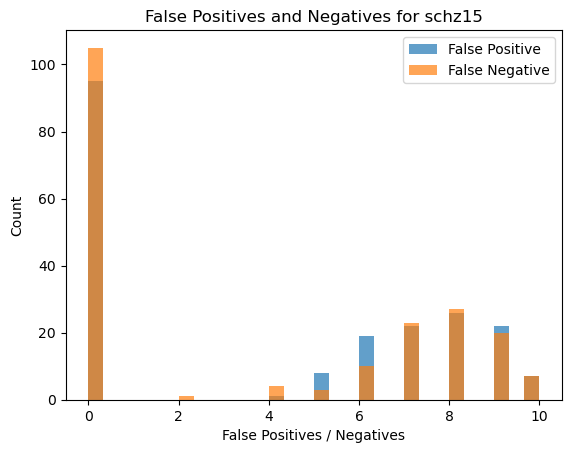

5400 5400


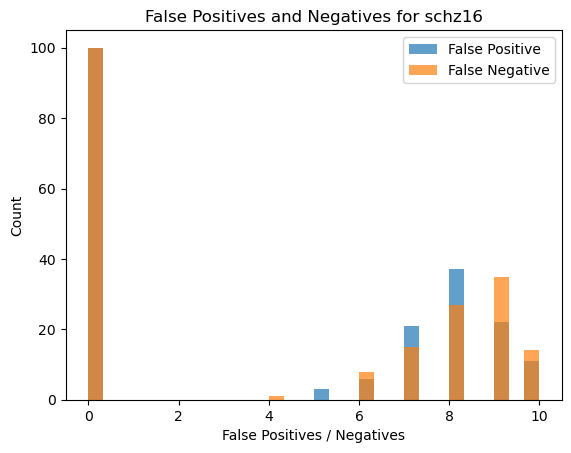

5400 5400


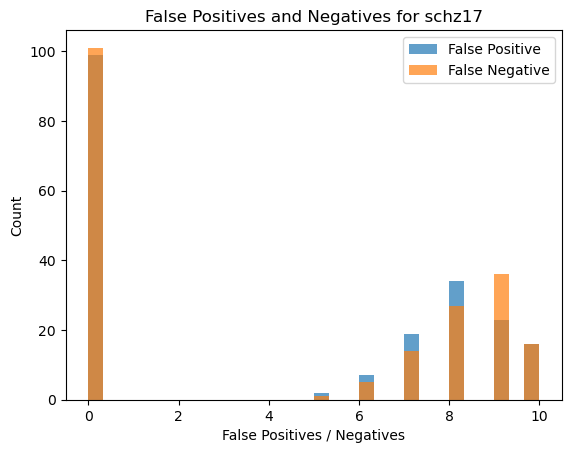

5400 5400


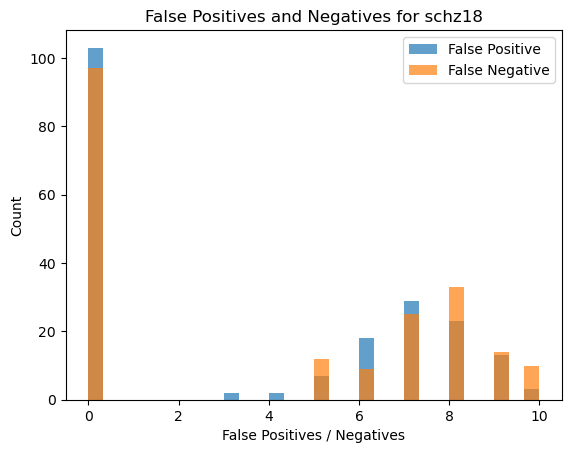

5400 5400


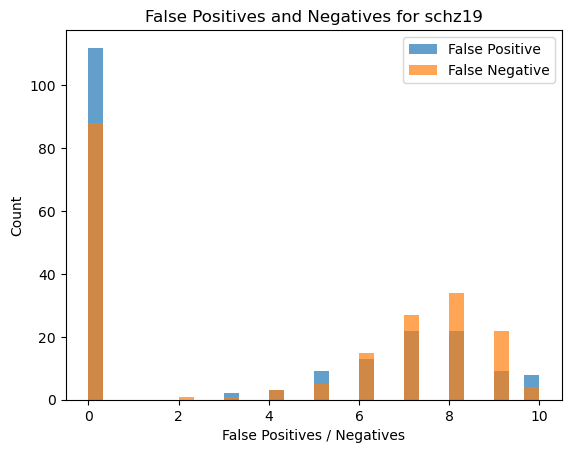

5400 5400


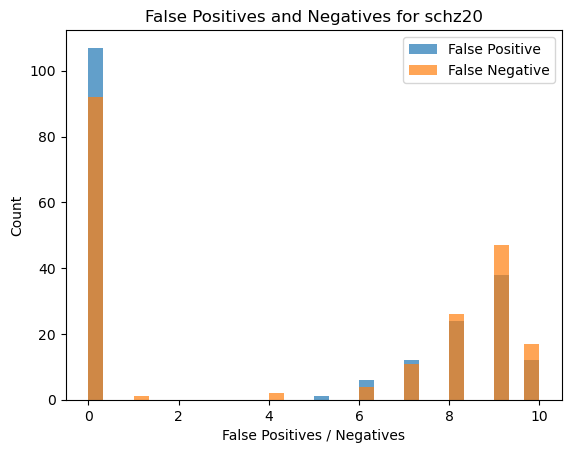

5400 5400


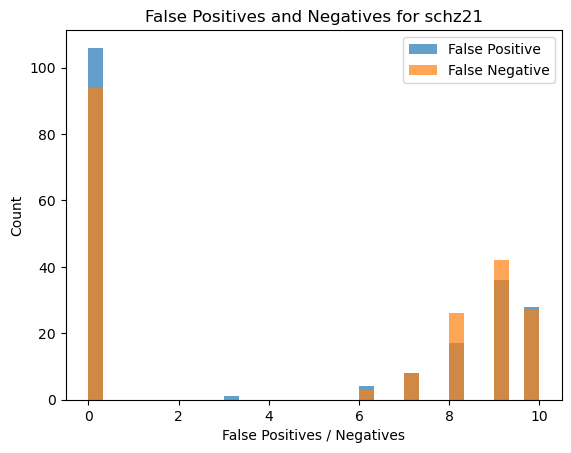

5400 5400


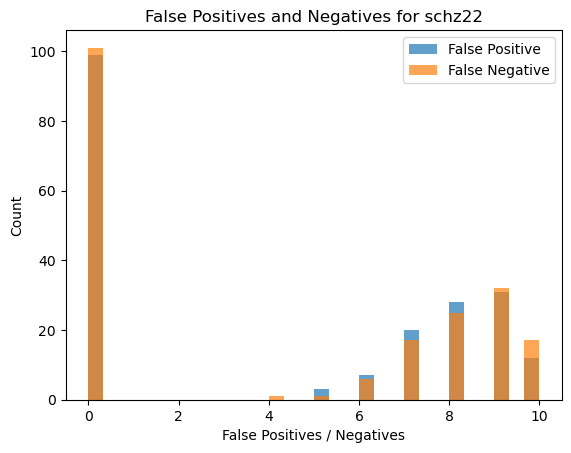

5400 5400


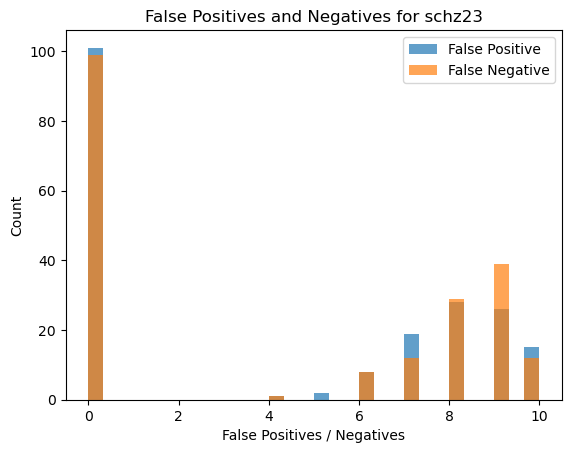

5400 5400


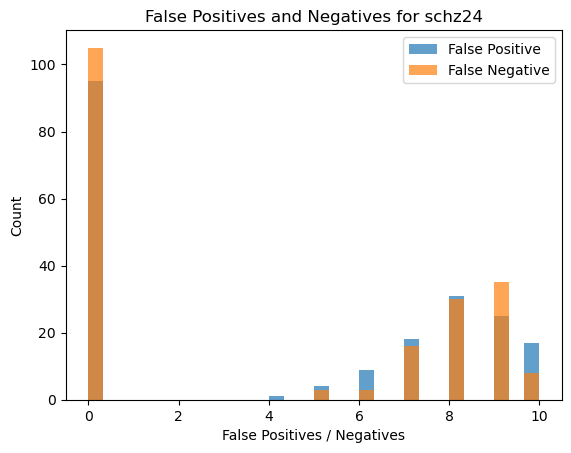

5400 5400


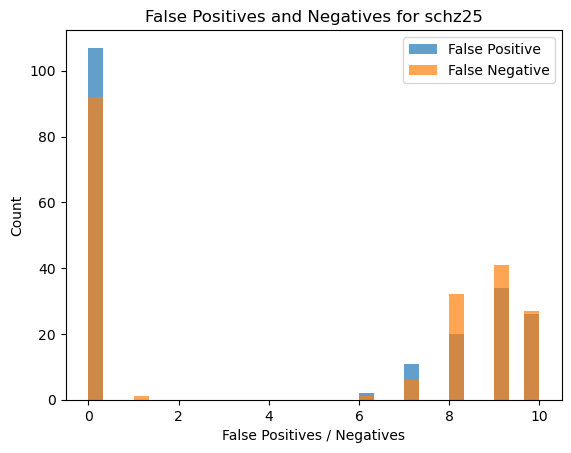

5400 5400


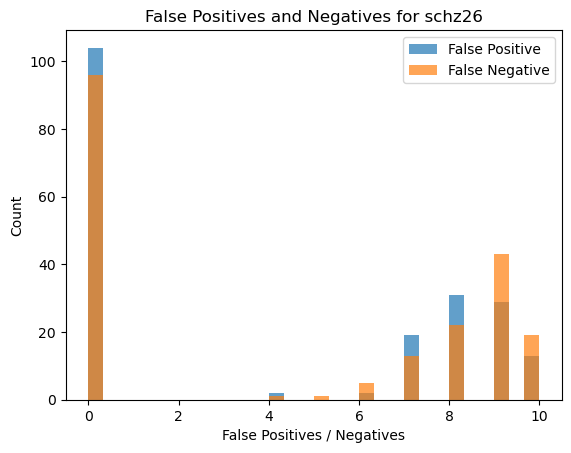

5400 5400


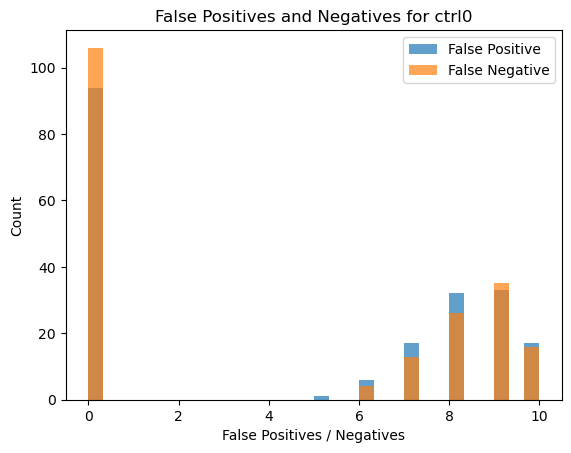

5400 5400


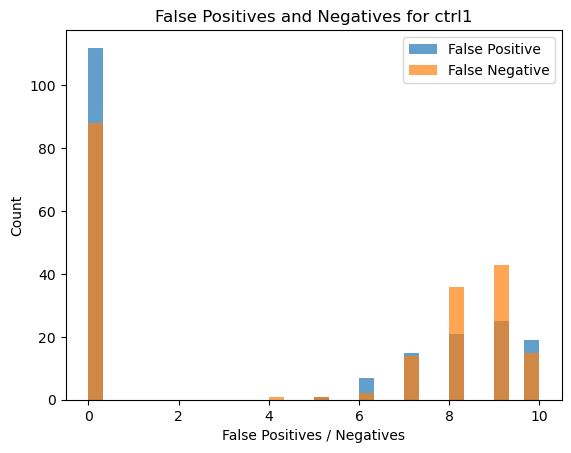

5400 5400


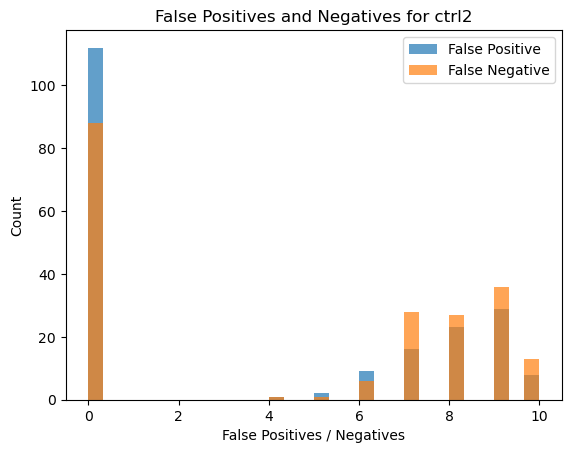

5400 5400


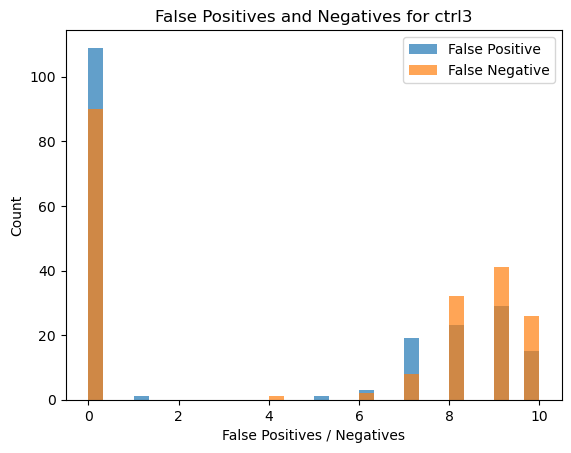

5400 5400


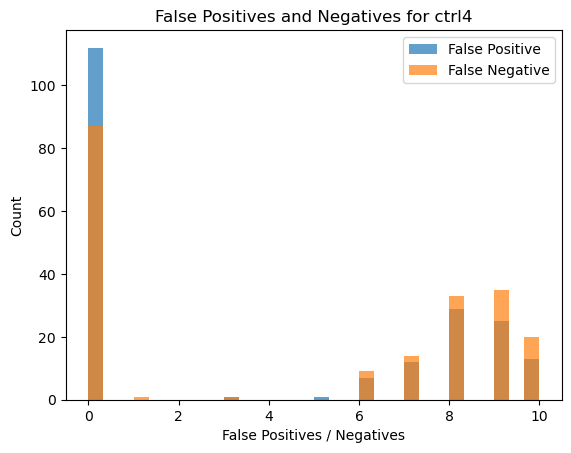

5400 5400


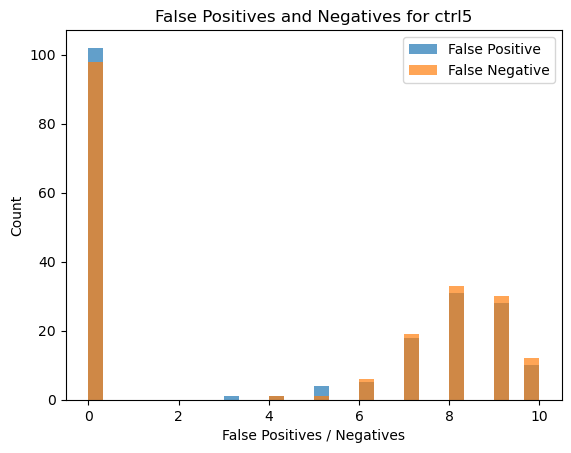

5400 5400


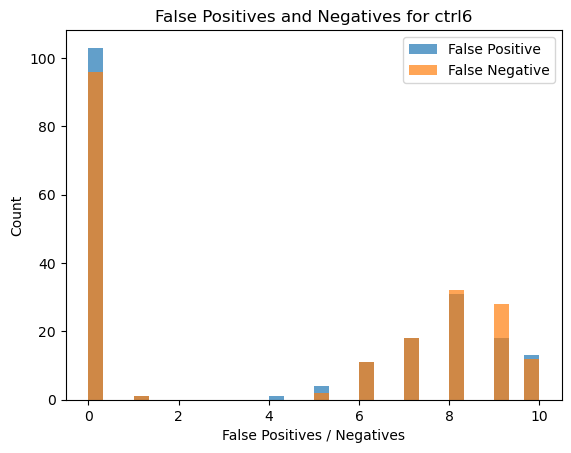

5400 5400


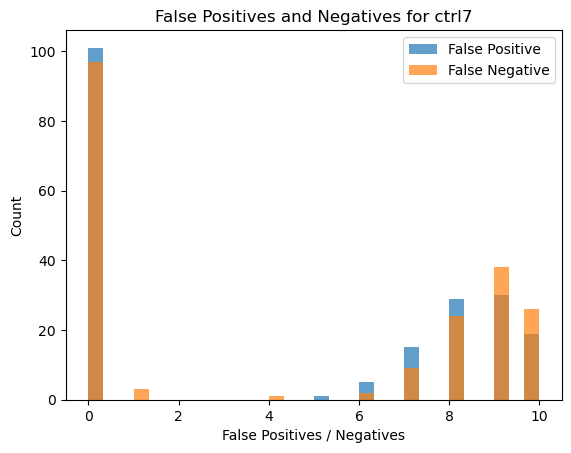

5400 5400


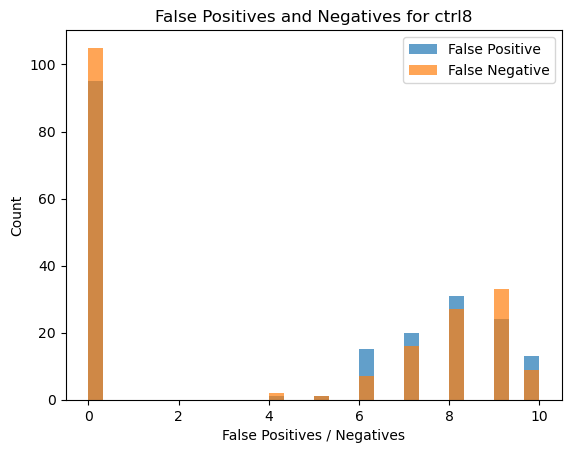

5400 5400


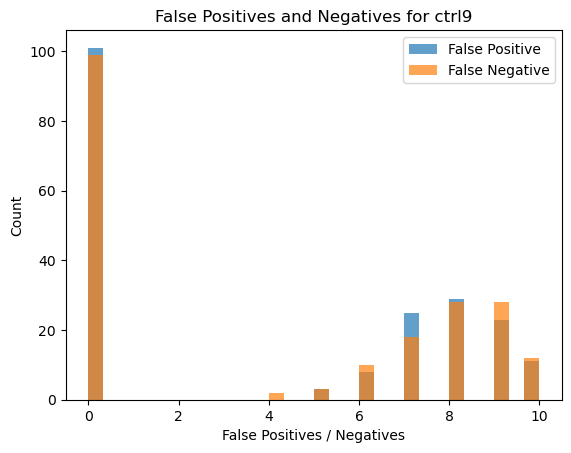

5400 5400


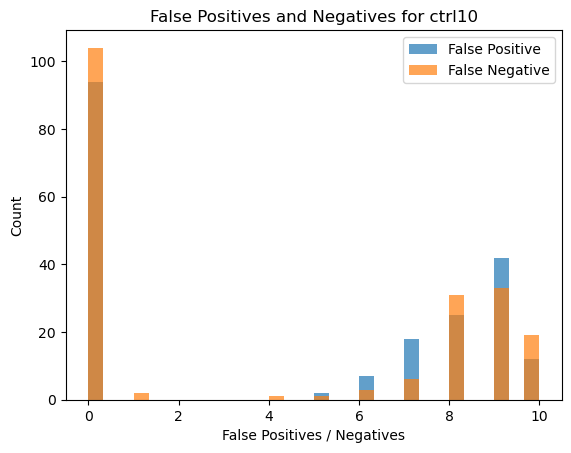

5400 5400


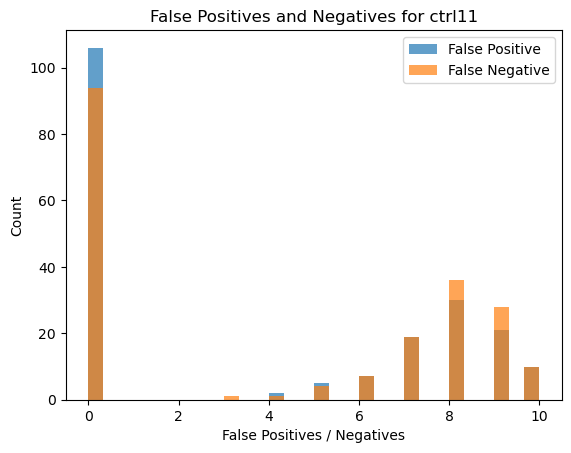

5400 5400


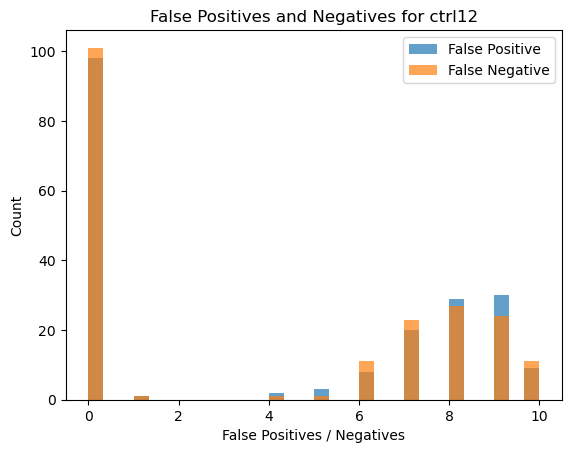

5400 5400


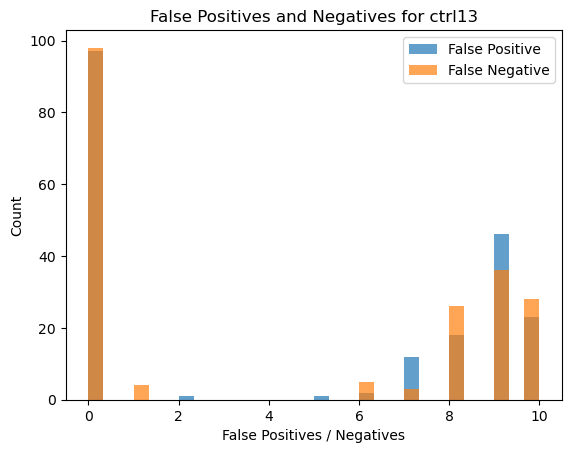

5400 5400


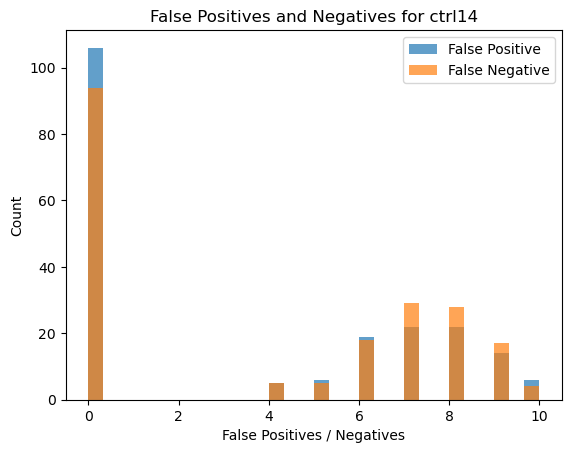

5400 5400


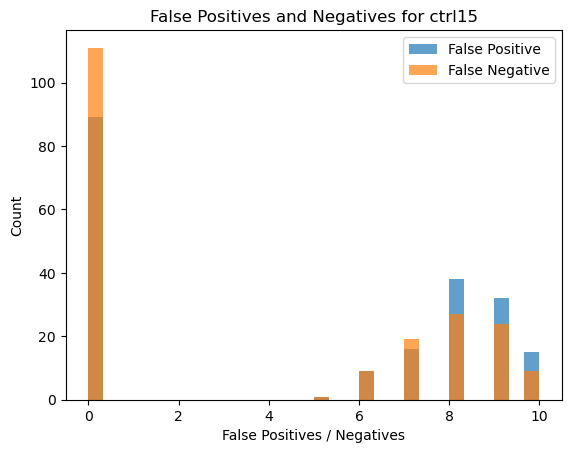

5400 5400


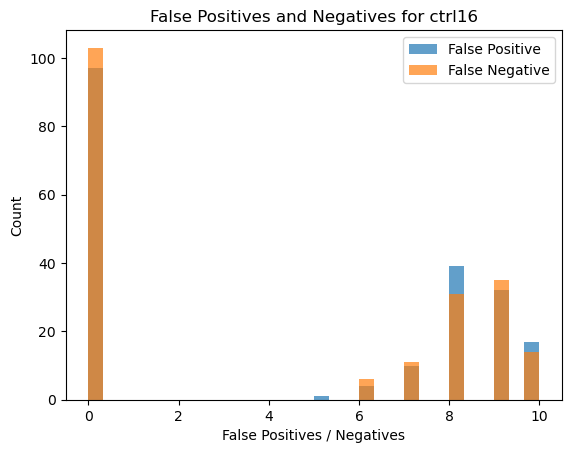

5400 5400


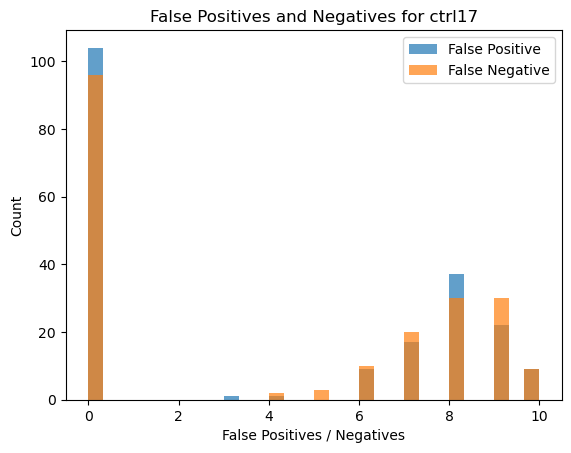

5400 5400


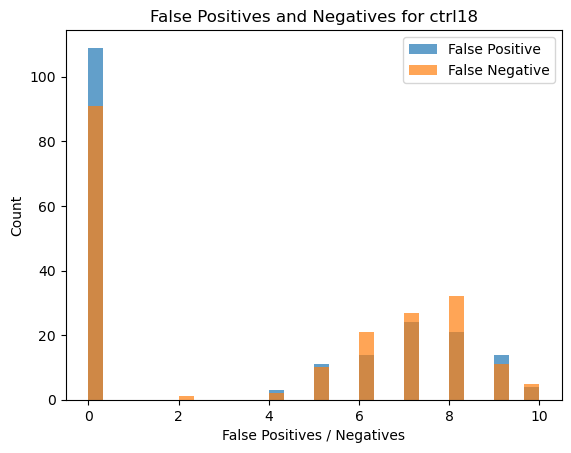

5400 5400


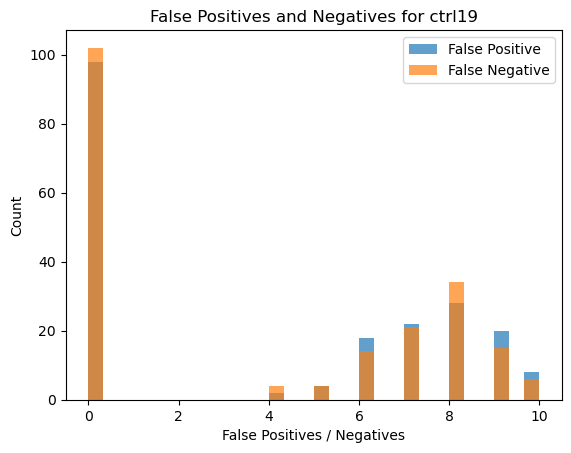

5400 5400


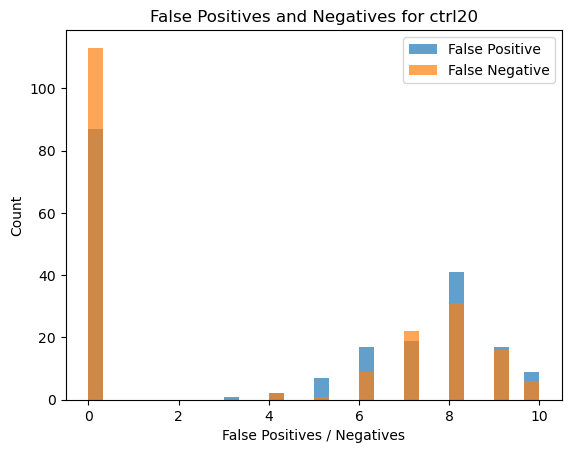

5400 5400


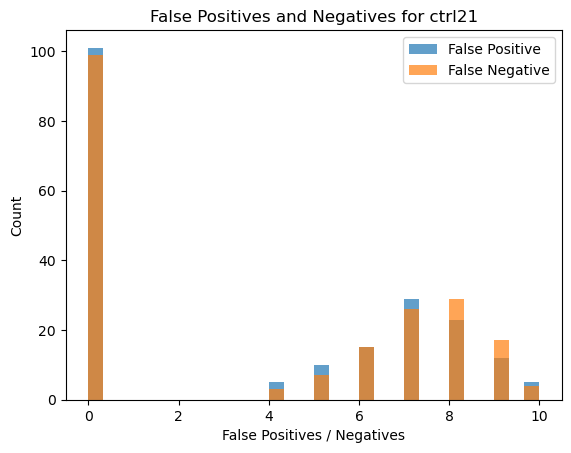

5400 5400


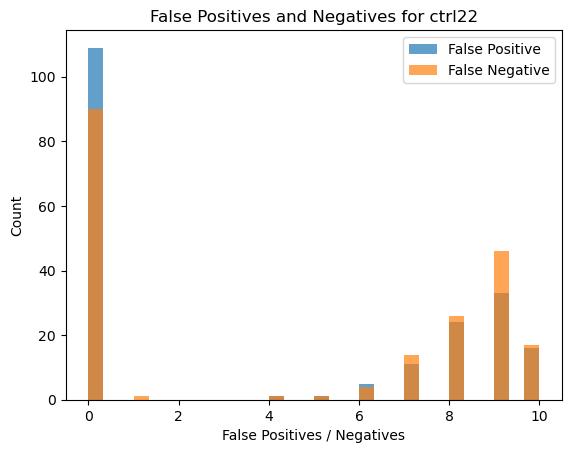

5400 5400


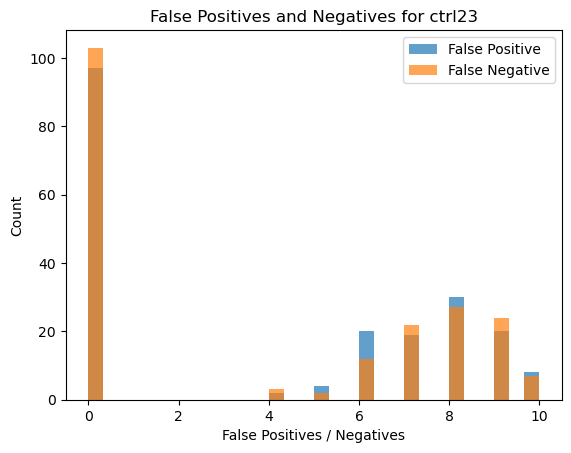

5400 5400


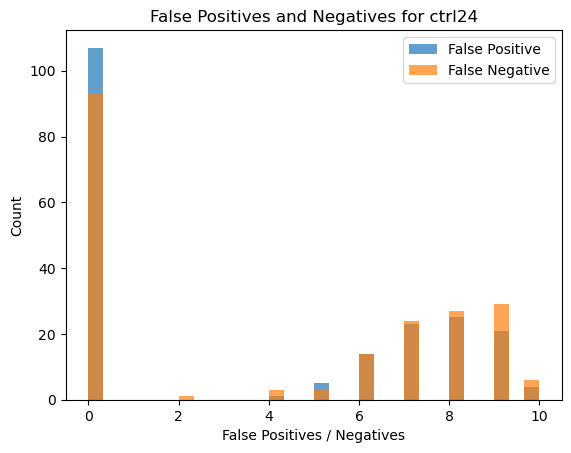

5400 5400


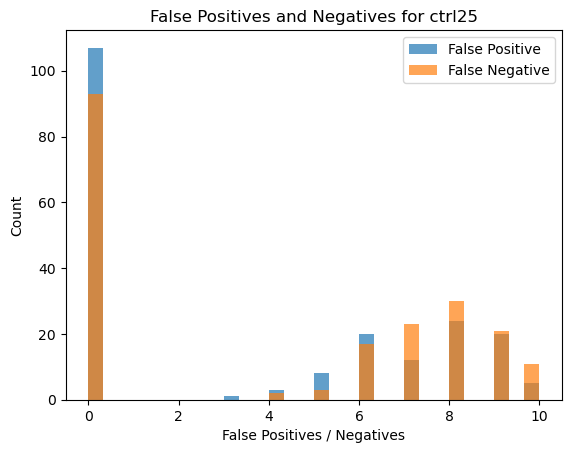

5400 5400


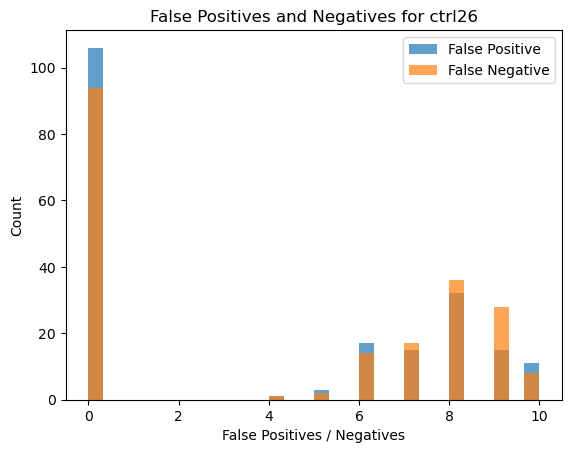

5400 5400


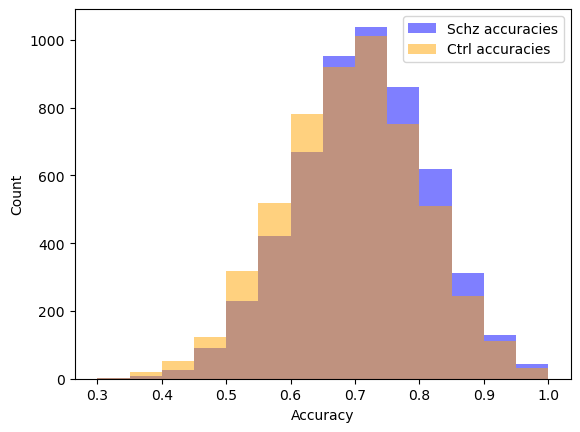

/var/folders/j2/mxj6mdd50nd0rsyvbthcl0br0000gn/T/ipykernel_31831/3003881284.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


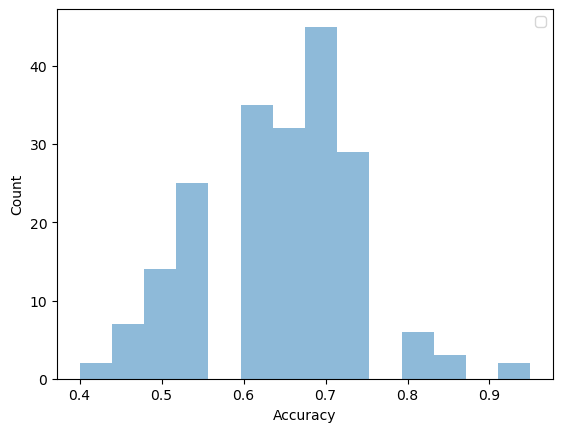

In [11]:
for subject in subjects:
    accuracies_all = np.array(accuracies_all)
    accuracies_all = accuracies_all.reshape(54, nsplits)
    plt.figure()
    plt.hist(FP_per_subj[subject], bins = 30, alpha=0.7, label='False Positive')
    plt.hist(FN_per_subj[subject], bins = 30, alpha=0.7, label='False Negative')
    plt.ylabel('Count')
    plt.xlabel('False Positives / Negatives')
    plt.legend()
    plt.title(f'False Positives and Negatives for {subject}')
    plt.show()
    print(len(accuracies_ctrl), len(accuracies_schz))

all_data = np.concatenate([accuracies_schz, accuracies_ctrl])
bins = np.linspace(np.min(all_data), np.max(all_data), 15)
plt.figure()
plt.hist(accuracies_schz, bins=bins, alpha=0.5, label='Schz accuracies', color='blue')
plt.hist(accuracies_ctrl, bins=bins, alpha=0.5, label='Ctrl accuracies', color='orange')
plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.legend()
plt.show()

all_data = np.concatenate([accuracies_schz, accuracies_ctrl])
bins = np.linspace(np.min(accuracies_all[4]), np.max(accuracies_all[4]), 15)
plt.figure()
plt.hist(accuracies_all[4], bins=bins, alpha=0.5)
plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.legend()
plt.show()

-10 -10
[np.float64(6.0), np.float64(-7.0), np.float64(-7.0), np.float64(-7.0), np.float64(-7.0), np.float64(-5.5), np.float64(-6.0), np.float64(-2.5), np.float64(6.0), np.float64(-4.0), np.float64(6.0), np.float64(-5.5), np.float64(4.0), np.float64(6.0), np.float64(-5.0), np.float64(7.0), np.float64(6.0), np.float64(-5.0), np.float64(-5.0), np.float64(4.5), np.float64(6.0), np.float64(-4.0), np.float64(-7.0), np.float64(5.0), np.float64(-5.5), np.float64(-6.0), np.float64(-6.0)]


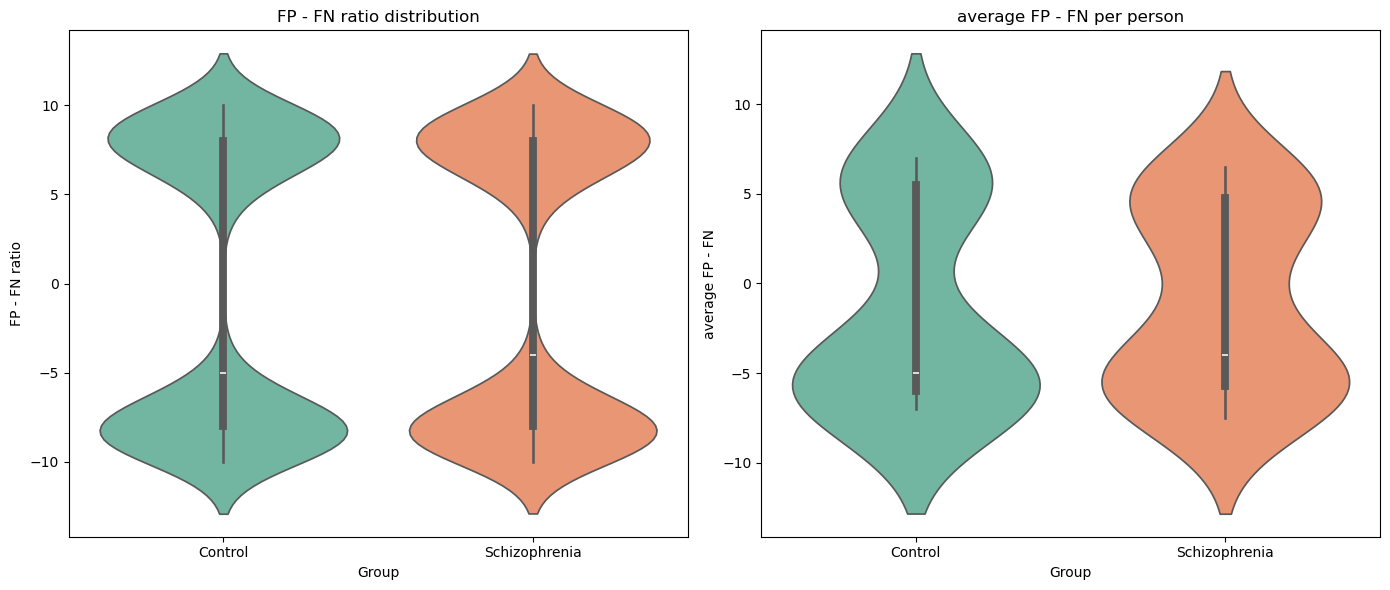

Mann-Whitney U ctrl: stat=142.000, p=0.2558
ctrl15 7.0
schz5 6.5
schz11 6.0
ctrl0 6.0
ctrl8 6.0
ctrl10 6.0
ctrl13 6.0
ctrl16 6.0
ctrl20 6.0
schz24 5.5
schz1 5.0
schz15 5.0
schz17 5.0
schz22 5.0
ctrl23 5.0
schz3 4.5
ctrl19 4.5
schz7 4.0
ctrl12 4.0
schz6 3.5
schz9 0.5
schz16 0.5
schz2 -0.5
ctrl7 -2.5
schz14 -4.0
ctrl9 -4.0
ctrl21 -4.0
schz0 -4.5
schz8 -4.5
schz13 -4.5
schz18 -5.0
schz23 -5.0
ctrl14 -5.0
ctrl17 -5.0
ctrl18 -5.0
schz4 -5.5
ctrl5 -5.5
ctrl11 -5.5
ctrl24 -5.5
schz12 -6.0
schz19 -6.0
schz26 -6.0
ctrl6 -6.0
ctrl25 -6.0
ctrl26 -6.0
schz10 -7.0
schz20 -7.0
schz21 -7.0
ctrl1 -7.0
ctrl2 -7.0
ctrl3 -7.0
ctrl4 -7.0
ctrl22 -7.0
schz25 -7.5


In [12]:

# Berechne ratio für jeden Split separat
ratios_per_subj = {}
for subj in subjects:
    ratios = []
    for fp, fn in zip(FP_per_subj[subj], FN_per_subj[subj]):
        ratios.append(fp - fn)
    ratios_per_subj[subj] = ratios

# Sammle ratios pro Gruppe
ratios_ctrl = [r for subj in subjects if 'ctrl' in subj 
               for r in ratios_per_subj[subj] if not np.isnan(r)]
ratios_schz = [r for subj in subjects if 'schz' in subj 
               for r in ratios_per_subj[subj] if not np.isnan(r)]
print(min(ratios_ctrl), min(ratios_schz))
df_ratio = pd.DataFrame({
    'FP - FN ratio': ratios_ctrl + ratios_schz,
    'Group': ['Control'] * len(ratios_ctrl) + ['Schizophrenia'] * len(ratios_schz)
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot der Verteilung
sns.violinplot(x='Group', y='FP - FN ratio', hue='Group',
               data=df_ratio, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('FP - FN ratio distribution')

# Oder: pro Person den Median mit Streuung
median_ratios_ctrl = [np.nanmedian(ratios_per_subj[s]) for s in subjects if 'ctrl' in s]
median_ratios_schz = [np.nanmedian(ratios_per_subj[s]) for s in subjects if 'schz' in s]
print(median_ratios_ctrl)

df_median = pd.DataFrame({
    'average FP - FN': median_ratios_ctrl + median_ratios_schz,
    'Group': ['Control'] * len(median_ratios_ctrl) + ['Schizophrenia'] * len(median_ratios_schz)
})
sns.violinplot(x='Group', y='average FP - FN', hue='Group',
               data=df_median, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('average FP - FN per person')
plt.tight_layout()
plt.show()

# Statistischer Test
stat, p = stats.wilcoxon(median_ratios_ctrl)
print(f"Mann-Whitney U ctrl: stat={stat:.3f}, p={p:.4f}")


# rank people of decreasing FP - FN ratio and see if they are mostly schz or ctrl
sorted_subjects = sorted(subjects, key=lambda s: np.nanmedian(ratios_per_subj[s]), reverse=True)
for s in sorted_subjects:
    print(s, np.nanmedian(ratios_per_subj[s]))